# GVH — Problème des trois corps — Pipeline 0.1

## Objectif

Construire un premier benchmark numérique du problème newtonien des trois corps et mesurer :

- la trajectoire des trois corps ;
- la conservation de l'énergie, de la quantité de mouvement et du moment cinétique ;
- la sensibilité aux conditions initiales ;
- les observables GVH appliquées à l'état dynamique global ;
- la forme de la fonction de survie des transitions ;
- les principales fréquences du mouvement ;
- la reproductibilité et la qualité numérique du pipeline.

Le notebook utilise des **unités sans dimension** avec \(G=1\).  
Il ne cherche pas une solution analytique générale : il produit une intégration numérique contrôlée.

## 1. Imports et configuration

In [2]:
import sys
import platform
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.integrate import solve_ivp
from scipy.optimize import curve_fit
from scipy.fft import rfft, rfftfreq

warnings.filterwarnings("ignore")

SEED = 42
rng = np.random.default_rng(SEED)

OUTPUT_DIR = Path("exports")
OUTPUT_DIR.mkdir(exist_ok=True)

print("Python :", sys.version.split()[0])
print("Plateforme :", platform.platform())
print("NumPy :", np.__version__)
print("Pandas :", pd.__version__)

Python : 3.12.13
Plateforme : Linux-6.6.122+-x86_64-with-glibc2.35
NumPy : 2.0.2
Pandas : 2.2.2


## 2. Paramètres physiques et numériques

Le scénario de base utilise trois masses égales. Les positions et vitesses initiales sont choisies de manière à produire une dynamique non triviale, avec centre de masse et quantité de mouvement corrigés.

In [3]:
G = 1.0
masses = np.array([1.0, 1.0, 1.0], dtype=float)

t0 = 0.0
t_max = 80.0
dt_export = 0.01
t_eval = np.arange(t0, t_max + dt_export, dt_export)

rtol = 1e-10
atol = 1e-12
softening = 1e-5

# Positions initiales : triangle légèrement asymétrique
r0 = np.array([
    [-1.00,  0.00],
    [ 1.00,  0.00],
    [ 0.10,  0.82]
], dtype=float)

# Vitesses initiales : rotation imparfaite + perturbation
v0 = np.array([
    [ 0.10,  0.42],
    [-0.16, -0.36],
    [ 0.06, -0.08]
], dtype=float)

# Correction du centre de masse et de la quantité de mouvement totale
r_cm = np.average(r0, axis=0, weights=masses)
v_cm = np.average(v0, axis=0, weights=masses)

r0 = r0 - r_cm
v0 = v0 - v_cm

y0 = np.concatenate([r0.ravel(), v0.ravel()])

print("Centre de masse initial :", np.average(r0, axis=0, weights=masses))
print("Vitesse du centre de masse :", np.average(v0, axis=0, weights=masses))

Centre de masse initial : [-2.77555756e-17  0.00000000e+00]
Vitesse du centre de masse : [ 0.00000000e+00 -9.25185854e-18]


## 3. Équations du mouvement

Pour chaque corps \(i\),

\[
\ddot{\mathbf r}_i
=
G\sum_{j\neq i}
m_j
\frac{\mathbf r_j-\mathbf r_i}
{\left(\|\mathbf r_j-\mathbf r_i\|^2+\varepsilon^2\right)^{3/2}}.
\]

Le petit paramètre \(\varepsilon\) sert uniquement à éviter une singularité numérique lors d'un rapprochement extrême.

In [4]:
def three_body_rhs(t, y, masses, G=1.0, softening=1e-5):
    n = len(masses)
    r = y[:2*n].reshape(n, 2)
    v = y[2*n:].reshape(n, 2)

    a = np.zeros_like(r)

    for i in range(n):
        for j in range(n):
            if i == j:
                continue
            dr = r[j] - r[i]
            dist2 = np.dot(dr, dr) + softening**2
            a[i] += G * masses[j] * dr / dist2**1.5

    return np.concatenate([v.ravel(), a.ravel()])

## 4. Intégration numérique

In [5]:
solution = solve_ivp(
    fun=lambda t, y: three_body_rhs(t, y, masses, G, softening),
    t_span=(t0, t_max),
    y0=y0,
    t_eval=t_eval,
    method="DOP853",
    rtol=rtol,
    atol=atol
)

if not solution.success:
    raise RuntimeError(solution.message)

n = len(masses)
positions = solution.y[:2*n].T.reshape(-1, n, 2)
velocities = solution.y[2*n:].T.reshape(-1, n, 2)
times = solution.t

print("Nombre d'états :", len(times))
print("Intervalle temporel :", times[0], "→", times[-1])

Nombre d'états : 8001
Intervalle temporel : 0.0 → 80.0


## 5. Visualisation des trajectoires

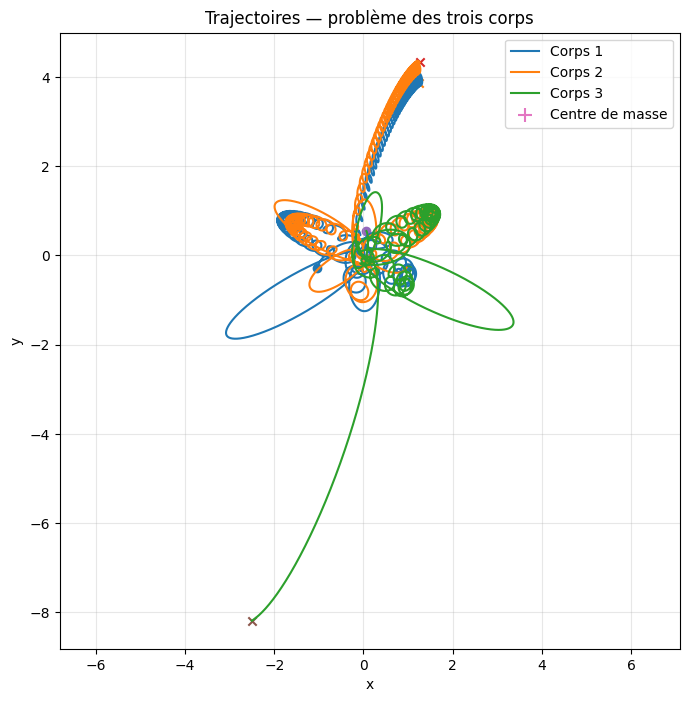

In [6]:
plt.figure(figsize=(8, 8))

for i in range(n):
    plt.plot(positions[:, i, 0], positions[:, i, 1], label=f"Corps {i+1}")
    plt.scatter(positions[0, i, 0], positions[0, i, 1], marker="o")
    plt.scatter(positions[-1, i, 0], positions[-1, i, 1], marker="x")

plt.scatter(0, 0, marker="+", s=100, label="Centre de masse")
plt.xlabel("x")
plt.ylabel("y")
plt.title("Trajectoires — problème des trois corps")
plt.axis("equal")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 6. Diagnostics de conservation

In [7]:
def total_energy(positions, velocities, masses, G=1.0, softening=1e-5):
    kinetic = 0.5 * np.sum(
        masses[None, :, None] * velocities**2,
        axis=(1, 2)
    )

    potential = np.zeros(len(positions))
    for i in range(len(masses)):
        for j in range(i + 1, len(masses)):
            dr = positions[:, j] - positions[:, i]
            dist = np.sqrt(np.sum(dr**2, axis=1) + softening**2)
            potential -= G * masses[i] * masses[j] / dist

    return kinetic + potential, kinetic, potential


def total_linear_momentum(velocities, masses):
    return np.sum(masses[None, :, None] * velocities, axis=1)


def total_angular_momentum_z(positions, velocities, masses):
    return np.sum(
        masses[None, :] *
        (positions[:, :, 0] * velocities[:, :, 1]
         - positions[:, :, 1] * velocities[:, :, 0]),
        axis=1
    )


energy, kinetic, potential = total_energy(
    positions, velocities, masses, G, softening
)
momentum = total_linear_momentum(velocities, masses)
angular_momentum = total_angular_momentum_z(
    positions, velocities, masses
)

energy_rel_error = np.abs((energy - energy[0]) / energy[0])
momentum_norm = np.linalg.norm(momentum, axis=1)
angular_rel_error = np.abs(
    (angular_momentum - angular_momentum[0])
    / max(abs(angular_momentum[0]), 1e-15)
)

diagnostics = pd.DataFrame({
    "time": times,
    "energy": energy,
    "kinetic": kinetic,
    "potential": potential,
    "energy_rel_error": energy_rel_error,
    "momentum_x": momentum[:, 0],
    "momentum_y": momentum[:, 1],
    "momentum_norm": momentum_norm,
    "angular_momentum_z": angular_momentum,
    "angular_rel_error": angular_rel_error
})

display(diagnostics.head())

print("Erreur relative max énergie :", energy_rel_error.max())
print("Norme max quantité de mouvement :", momentum_norm.max())
print("Erreur relative max moment cinétique :", angular_rel_error.max())

,time,energy,kinetic,potential,energy_rel_error,momentum_x,momentum_y,momentum_norm,angular_momentum_z,angular_rel_error
0,0.00,-1.874456,0.175733,-2.050189,0.000000e+00,0.000000e+00,-2.775558e-17,2.775558e-17,-0.836533,0.000000e+00
1,0.01,-1.874456,0.178058,-2.052514,2.369163e-16,-1.387779e-17,-2.775558e-17,3.103168e-17,-0.836533,1.327171e-16
2,0.02,-1.874456,0.180566,-2.055022,1.184582e-16,-2.081668e-17,-1.387779e-17,2.501854e-17,-0.836533,1.327171e-16
3,0.03,-1.874456,0.183260,-2.057716,2.511313e-14,2.081668e-17,-6.938894e-17,7.244418e-17,-0.836533,3.666974e-13
4,0.04,-1.874456,0.186141,-2.060597,3.261153e-13,0.000000e+00,-6.938894e-17,6.938894e-17,-0.836533,1.923071e-12


Erreur relative max énergie : 2.6750671277902354e-07
Norme max quantité de mouvement : 3.3123244500560894e-14
Erreur relative max moment cinétique : 2.919281010742761e-09


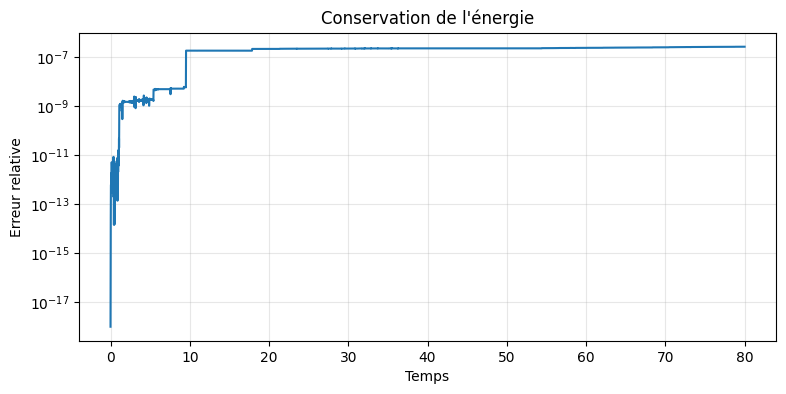

In [8]:
plt.figure(figsize=(9, 4))
plt.semilogy(times, np.maximum(energy_rel_error, 1e-18))
plt.xlabel("Temps")
plt.ylabel("Erreur relative")
plt.title("Conservation de l'énergie")
plt.grid(True, alpha=0.3)
plt.show()

## 7. Construction de l'état dynamique GVH

L'état global est le vecteur concaténé des positions et vitesses :

\[
X(t)=
(x_1,y_1,x_2,y_2,x_3,y_3,
v_{x1},v_{y1},\ldots,v_{x3},v_{y3}).
\]

On standardise chaque coordonnée avant de mesurer les transitions afin d'éviter qu'une variable domine artificiellement les autres.

In [9]:
state = np.hstack([
    positions.reshape(len(times), -1),
    velocities.reshape(len(times), -1)
])

state_mean = state.mean(axis=0)
state_std = state.std(axis=0)
state_std[state_std == 0] = 1.0

state_z = (state - state_mean) / state_std

delta_state = np.diff(state_z, axis=0)
D_T = np.linalg.norm(delta_state, axis=1)

D_T_max = D_T.max()
u = D_T / D_T_max if D_T_max > 0 else np.zeros_like(D_T)

q = 0.95
u_c = np.quantile(u, q)
D_c = np.quantile(D_T, q)
R_super = np.mean(u > u_c)

D_T_mean = D_T.mean()
S_T = D_T.std(ddof=1)
S_T_norm = S_T / D_T_mean if D_T_mean > 0 else np.nan

print("D_T_mean =", D_T_mean)
print("S_T =", S_T)
print("S_T_norm =", S_T_norm)
print("D_c =", D_c)
print("u_c =", u_c)
print("R_super =", R_super)

D_T_mean = 0.2727562560198964
S_T = 0.9685927849803511
S_T_norm = 3.551129492368807
D_c = 0.6807654044819522
u_c = 0.037467414462870115
R_super = 0.05


## 8. Observables angulaires

On calcule l'angle entre deux vecteurs de transition successifs dans l'espace d'état standardisé.

In [10]:
a = delta_state[:-1]
b = delta_state[1:]

norm_a = np.linalg.norm(a, axis=1)
norm_b = np.linalg.norm(b, axis=1)

valid = (norm_a > 0) & (norm_b > 0)
cos_theta = np.sum(a[valid] * b[valid], axis=1) / (
    norm_a[valid] * norm_b[valid]
)
cos_theta = np.clip(cos_theta, -1.0, 1.0)
theta_deg = np.degrees(np.arccos(cos_theta))

theta_mean = theta_deg.mean()
theta_median = np.median(theta_deg)
theta_std = theta_deg.std(ddof=1)
theta_max = theta_deg.max()
R_170 = np.mean(theta_deg >= 170.0)
R_175 = np.mean(theta_deg >= 175.0)
R_180 = np.mean(theta_deg >= 179.0)

print("theta_mean =", theta_mean)
print("theta_median =", theta_median)
print("theta_std =", theta_std)
print("theta_max =", theta_max)
print("R_170 =", R_170)
print("R_175 =", R_175)
print("R_180 =", R_180)

theta_mean = 4.565765422567737
theta_median = 1.9588635029549823
theta_std = 12.132942605654517
theta_max = 174.39723236684716
R_170 = 0.00025003125390673836
R_175 = 0.0
R_180 = 0.0


## 9. Fonction de survie et comparaison de modèles

In [11]:
u_grid = np.linspace(0.0, 1.0, 250)
survival = np.array([(u > x).mean() for x in u_grid])

def exponential_model(x, A, B):
    return A * np.exp(-B * x)

def logistic_model(x, x0, k):
    return 1.0 / (1.0 + np.exp(k * (x - x0)))

def weibull_model(x, lam, k):
    return np.exp(-np.maximum(x / lam, 0.0)**k)

def fit_quality(y, yhat, n_params):
    resid = y - yhat
    rss = np.sum(resid**2)
    rmse = np.sqrt(np.mean(resid**2))
    tss = np.sum((y - y.mean())**2)
    r2 = 1.0 - rss / tss if tss > 0 else np.nan
    aic = len(y) * np.log(max(rss / len(y), 1e-300)) + 2 * n_params
    return r2, rmse, aic

fit_rows = []
fit_curves = {}

try:
    popt_exp, _ = curve_fit(
        exponential_model,
        u_grid,
        survival,
        p0=[1.0, 5.0],
        bounds=([0.0, 0.0], [10.0, 1e4]),
        maxfev=20000
    )
    yhat = exponential_model(u_grid, *popt_exp)
    r2, rmse, aic = fit_quality(survival, yhat, 2)
    fit_rows.append(["Exponentielle", *popt_exp, np.nan, r2, rmse, aic])
    fit_curves["Exponentielle"] = yhat
except Exception as exc:
    print("Échec fit exponentiel :", exc)

try:
    popt_log, _ = curve_fit(
        logistic_model,
        u_grid,
        survival,
        p0=[0.5, 10.0],
        bounds=([0.0, 0.01], [1.0, 1e3]),
        maxfev=20000
    )
    yhat = logistic_model(u_grid, *popt_log)
    r2, rmse, aic = fit_quality(survival, yhat, 2)
    fit_rows.append(["Logistique", *popt_log, np.nan, r2, rmse, aic])
    fit_curves["Logistique"] = yhat
except Exception as exc:
    print("Échec fit logistique :", exc)

try:
    popt_wei, _ = curve_fit(
        weibull_model,
        u_grid,
        survival,
        p0=[0.5, 2.0],
        bounds=([1e-5, 0.01], [10.0, 100.0]),
        maxfev=20000
    )
    yhat = weibull_model(u_grid, *popt_wei)
    r2, rmse, aic = fit_quality(survival, yhat, 2)
    fit_rows.append(["Weibull", *popt_wei, np.nan, r2, rmse, aic])
    fit_curves["Weibull"] = yhat
except Exception as exc:
    print("Échec fit Weibull :", exc)

fit_models = pd.DataFrame(
    fit_rows,
    columns=["modele", "parametre_1", "parametre_2",
             "parametre_3", "R2", "RMSE", "AIC"]
).sort_values("AIC")

display(fit_models)

,modele,parametre_1,parametre_2,parametre_3,R2,RMSE,AIC
2,Weibull,0.008239,0.830900,NaN,0.984164,0.010002,-2298.499432
0,Exponentielle,0.991554,116.183801,NaN,0.981343,0.010856,-2257.509171
1,Logistique,0.006813,264.884459,NaN,0.948199,0.018090,-2002.211345


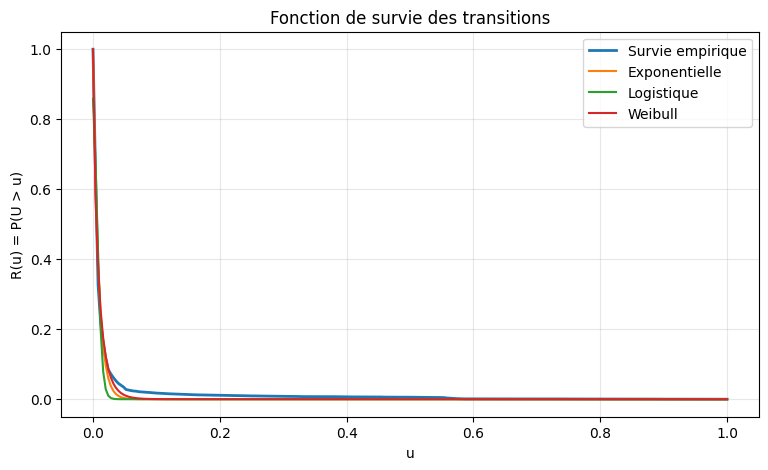

In [12]:
plt.figure(figsize=(9, 5))
plt.plot(u_grid, survival, label="Survie empirique", linewidth=2)

for name, curve in fit_curves.items():
    plt.plot(u_grid, curve, label=name)

plt.xlabel("u")
plt.ylabel("R(u) = P(U > u)")
plt.title("Fonction de survie des transitions")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 10. Sensibilité aux conditions initiales

Une seconde trajectoire est calculée avec une perturbation infinitésimale.  
La divergence fournit un indicateur de chaos de type exposant de Lyapunov à temps fini.

In [13]:
epsilon0 = 1e-9
perturbation = np.zeros_like(y0)
perturbation[0] = epsilon0

y0_shadow = y0 + perturbation

shadow = solve_ivp(
    fun=lambda t, y: three_body_rhs(t, y, masses, G, softening),
    t_span=(t0, t_max),
    y0=y0_shadow,
    t_eval=t_eval,
    method="DOP853",
    rtol=rtol,
    atol=atol
)

if not shadow.success:
    raise RuntimeError(shadow.message)

separation = np.linalg.norm((shadow.y - solution.y).T, axis=1)
separation_safe = np.maximum(separation, 1e-300)

# Ajustement dans une fenêtre où la divergence reste ni trop petite ni saturée
mask_lyap = (
    (times > 1.0) &
    (separation_safe > 10 * epsilon0) &
    (separation_safe < 1e-2)
)

if mask_lyap.sum() >= 10:
    coeffs = np.polyfit(
        times[mask_lyap],
        np.log(separation_safe[mask_lyap] / epsilon0),
        1
    )
    lambda_ft = coeffs[0]
else:
    lambda_ft = np.nan

print("Indicateur de Lyapunov à temps fini =", lambda_ft)

Indicateur de Lyapunov à temps fini = 0.7479258276287727


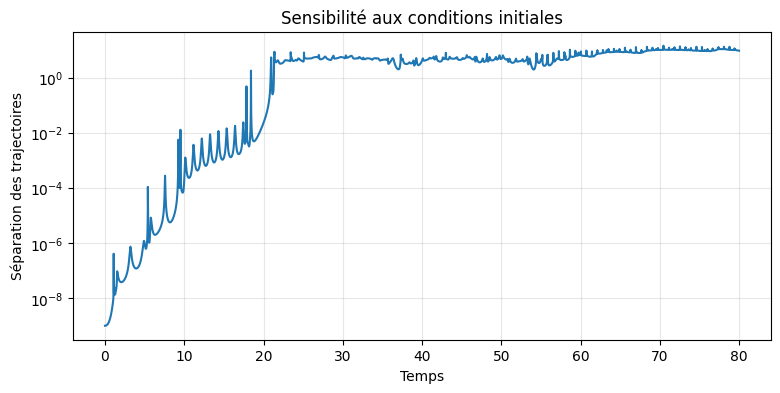

In [ ]:
plt.figure(figsize=(9, 4))
plt.semilogy(times, separation_safe)
plt.xlabel("Temps")
plt.ylabel("Séparation des trajectoires")
plt.title("Sensibilité aux conditions initiales")
plt.grid(True, alpha=0.3)
plt.show()

## 11. Analyse fréquentielle

On analyse ici la coordonnée \(x\) du premier corps.  
La même méthode pourra être étendue aux distances mutuelles, à l'énergie cinétique ou aux observables GVH.

In [14]:
signal = positions[:, 0, 0] - positions[:, 0, 0].mean()
freqs = rfftfreq(len(signal), d=dt_export)
spectrum = np.abs(rfft(signal))

valid_freq = freqs > 0
freqs_nonzero = freqs[valid_freq]
spectrum_nonzero = spectrum[valid_freq]

top_idx = np.argsort(spectrum_nonzero)[-10:][::-1]
fft_top = pd.DataFrame({
    "frequency": freqs_nonzero[top_idx],
    "period": 1.0 / freqs_nonzero[top_idx],
    "amplitude": spectrum_nonzero[top_idx]
})

display(fft_top)

,frequency,period,amplitude
0,0.012498,80.01000,6127.830518
1,0.037495,26.67000,2406.134795
2,0.049994,20.00250,2268.838083
3,0.024997,40.00500,1491.140730
4,0.074991,13.33500,670.621708
5,0.124984,8.00100,661.601338
6,0.062492,16.00200,509.203983
7,0.099988,10.00125,419.065437
8,0.174978,5.71500,290.090354
9,0.112486,8.89000,268.356953


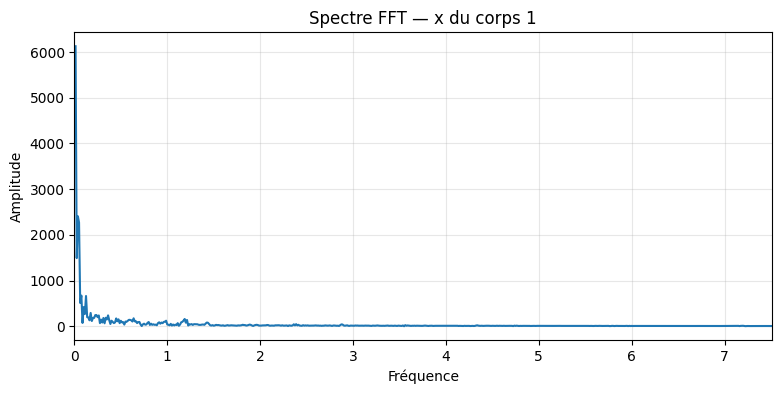

In [15]:
plt.figure(figsize=(9, 4))
plt.plot(freqs_nonzero, spectrum_nonzero)
plt.xlim(0, np.quantile(freqs_nonzero, 0.15))
plt.xlabel("Fréquence")
plt.ylabel("Amplitude")
plt.title("Spectre FFT — x du corps 1")
plt.grid(True, alpha=0.3)
plt.show()

## 12. Tableau final des observables GVH

In [16]:
best_model = fit_models.iloc[0]["modele"] if len(fit_models) else None
best_r2 = fit_models.iloc[0]["R2"] if len(fit_models) else np.nan
best_rmse = fit_models.iloc[0]["RMSE"] if len(fit_models) else np.nan
best_aic = fit_models.iloc[0]["AIC"] if len(fit_models) else np.nan

A_H = np.nan
B_H = np.nan

if "Exponentielle" in fit_models["modele"].values:
    exp_row = fit_models.loc[fit_models["modele"] == "Exponentielle"].iloc[0]
    A_H = exp_row["parametre_1"]
    B_H = exp_row["parametre_2"]

observables = pd.DataFrame({
    "Observable": [
        "D_T_mean",
        "S_T",
        "S_T_norm",
        "D_c",
        "u_c",
        "R_super",
        "A_H",
        "B_H",
        "theta_mean",
        "theta_median",
        "theta_std",
        "theta_max",
        "R_170",
        "R_175",
        "R_180",
        "lambda_finite_time",
        "energy_rel_error_max",
        "momentum_norm_max",
        "angular_rel_error_max",
        "best_survival_model",
        "best_survival_R2",
        "best_survival_RMSE",
        "best_survival_AIC"
    ],
    "Valeur": [
        D_T_mean,
        S_T,
        S_T_norm,
        D_c,
        u_c,
        R_super,
        A_H,
        B_H,
        theta_mean,
        theta_median,
        theta_std,
        theta_max,
        R_170,
        R_175,
        R_180,
        lambda_ft,
        energy_rel_error.max(),
        momentum_norm.max(),
        angular_rel_error.max(),
        best_model,
        best_r2,
        best_rmse,
        best_aic
    ]
})

display(observables)

,Observable,Valeur
0,D_T_mean,0.272756
1,S_T,0.968593
2,S_T_norm,3.551129
3,D_c,0.680765
4,u_c,0.037467
5,R_super,0.05
6,A_H,0.991554
7,B_H,116.183801
8,theta_mean,4.565765
9,theta_median,1.958864


## 13. Exports

In [17]:
trajectory_df = pd.DataFrame({"time": times})

for i in range(n):
    trajectory_df[f"x_{i+1}"] = positions[:, i, 0]
    trajectory_df[f"y_{i+1}"] = positions[:, i, 1]
    trajectory_df[f"vx_{i+1}"] = velocities[:, i, 0]
    trajectory_df[f"vy_{i+1}"] = velocities[:, i, 1]

transition_df = pd.DataFrame({
    "time": times[1:],
    "D_T": D_T,
    "u": u,
    "is_supercritical": u > u_c
})

angle_df = pd.DataFrame({
    "time": times[2:][valid],
    "theta_deg": theta_deg
})

survival_df = pd.DataFrame({
    "u_grid": u_grid,
    "survival_empirical": survival
})

trajectory_df.to_csv(
    OUTPUT_DIR / "GVH_Three_Body_Trajectory_0.1.csv",
    index=False
)
diagnostics.to_csv(
    OUTPUT_DIR / "GVH_Three_Body_Conservation_0.1.csv",
    index=False
)
transition_df.to_csv(
    OUTPUT_DIR / "GVH_Three_Body_Transitions_0.1.csv",
    index=False
)
angle_df.to_csv(
    OUTPUT_DIR / "GVH_Three_Body_Angles_0.1.csv",
    index=False
)
survival_df.to_csv(
    OUTPUT_DIR / "GVH_Three_Body_Survival_0.1.csv",
    index=False
)
fit_models.to_csv(
    OUTPUT_DIR / "GVH_Three_Body_Models_0.1.csv",
    index=False
)
fft_top.to_csv(
    OUTPUT_DIR / "GVH_Three_Body_FFT_0.1.csv",
    index=False
)
observables.to_csv(
    OUTPUT_DIR / "GVH_Three_Body_Observables_0.1.csv",
    index=False
)

print("Exports terminés :")
for path in sorted(OUTPUT_DIR.glob("GVH_Three_Body_*_0.1.csv")):
    print("-", path.name)

Exports terminés :
- GVH_Three_Body_Angles_0.1.csv
- GVH_Three_Body_Conservation_0.1.csv
- GVH_Three_Body_FFT_0.1.csv
- GVH_Three_Body_Models_0.1.csv
- GVH_Three_Body_Observables_0.1.csv
- GVH_Three_Body_Survival_0.1.csv
- GVH_Three_Body_Trajectory_0.1.csv
- GVH_Three_Body_Transitions_0.1.csv


## 14. Critères de validation du pipeline 0.1

Le pipeline peut être considéré comme numériquement acceptable si :

1. l'intégrateur termine sans erreur ;
2. l'erreur relative maximale sur l'énergie reste faible ;
3. la quantité de mouvement totale reste proche de zéro ;
4. le moment cinétique reste stable ;
5. les observables GVH sont finies ;
6. les exports sont générés ;
7. la trajectoire perturbée permet d'estimer ou au moins de visualiser la divergence ;
8. les résultats sont reproductibles pour les mêmes paramètres.

## Étapes suivantes proposées

- **0.2** : ajouter plusieurs familles de conditions initiales ;
- **0.3** : comparer solution périodique en huit, système hiérarchique et cas chaotique ;
- **0.4** : utiliser un intégrateur symplectique ;
- **0.5** : mesurer les exposants de Lyapunov avec renormalisation périodique ;
- **0.6** : créer un notebook comparatif qui charge uniquement les CSV exportés.

## 15 Distances mutuelles entre les trois corps

On calcule les distances :

\[
r_{12}(t), \quad r_{13}(t), \quad r_{23}(t)
\]

afin d’identifier les rapprochements gravitationnels, les rencontres serrées et les éventuelles phases de formation d’un système binaire.

In [18]:
# Distances mutuelles entre les trois corps

r12 = np.linalg.norm(positions[:, 1] - positions[:, 0], axis=1)
r13 = np.linalg.norm(positions[:, 2] - positions[:, 0], axis=1)
r23 = np.linalg.norm(positions[:, 2] - positions[:, 1], axis=1)

distances_df = pd.DataFrame({
    "time": times,
    "r12": r12,
    "r13": r13,
    "r23": r23
})

display(distances_df.head())

,time,r12,r13,r23
0,0.00,2.000000,1.372006,1.217539
1,0.01,1.997344,1.368645,1.217732
2,0.02,1.994575,1.365181,1.217791
3,0.03,1.991694,1.361614,1.217718
4,0.04,1.988700,1.357943,1.217511


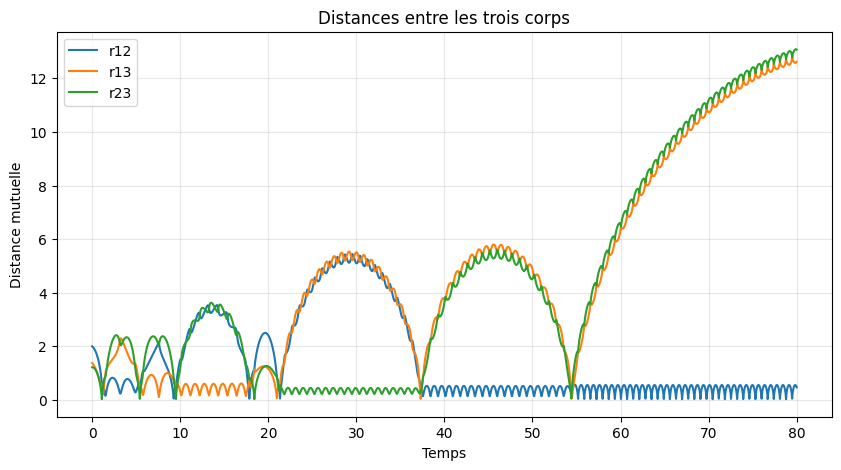

In [19]:
plt.figure(figsize=(10, 5))

plt.plot(times, r12, label="r12")
plt.plot(times, r13, label="r13")
plt.plot(times, r23, label="r23")

plt.xlabel("Temps")
plt.ylabel("Distance mutuelle")
plt.title("Distances entre les trois corps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 16 Distances minimales et instants de rapprochement maximal

On recherche, pour chaque paire, la distance minimale atteinte et le temps correspondant.

In [20]:
# Indices des distances minimales

idx_min_12 = np.argmin(r12)
idx_min_13 = np.argmin(r13)
idx_min_23 = np.argmin(r23)

minima_distances = pd.DataFrame({
    "paire": ["1-2", "1-3", "2-3"],
    "distance_min": [
        r12[idx_min_12],
        r13[idx_min_13],
        r23[idx_min_23]
    ],
    "temps_distance_min": [
        times[idx_min_12],
        times[idx_min_13],
        times[idx_min_23]
    ]
})

display(minima_distances)

,paire,distance_min,temps_distance_min
0,1-2,0.024983,66.99
1,1-3,0.037589,37.31
2,2-3,0.024897,18.42


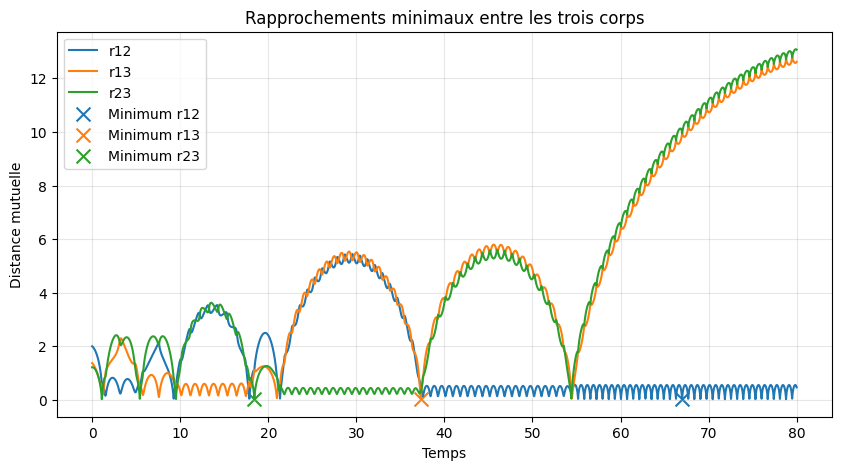

In [21]:
plt.figure(figsize=(10, 5))

plt.plot(times, r12, label="r12")
plt.plot(times, r13, label="r13")
plt.plot(times, r23, label="r23")

plt.scatter(
    times[idx_min_12],
    r12[idx_min_12],
    marker="x",
    s=100,
    label="Minimum r12"
)

plt.scatter(
    times[idx_min_13],
    r13[idx_min_13],
    marker="x",
    s=100,
    label="Minimum r13"
)

plt.scatter(
    times[idx_min_23],
    r23[idx_min_23],
    marker="x",
    s=100,
    label="Minimum r23"
)

plt.xlabel("Temps")
plt.ylabel("Distance mutuelle")
plt.title("Rapprochements minimaux entre les trois corps")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 17 Détection des rencontres serrées locales

Les minima globaux ne décrivent qu'un seul événement par paire.

On détecte maintenant les minima locaux des distances mutuelles afin
d'identifier les principales rencontres gravitationnelles au cours de la
simulation.

In [22]:
from scipy.signal import find_peaks

# Détection des minima locaux :
# un minimum de distance correspond à un pic de -r(t)

distance_series = {
    "1-2": r12,
    "1-3": r13,
    "2-3": r23
}

encounter_rows = []

for pair, distance in distance_series.items():

    minima_indices, properties = find_peaks(
        -distance,
        distance=10,       # séparation minimale de 10 pas temporels
        prominence=0.01    # élimine les très petites oscillations numériques
    )

    for idx in minima_indices:
        encounter_rows.append({
            "paire": pair,
            "index": idx,
            "temps": times[idx],
            "distance": distance[idx]
        })

encounters_df = pd.DataFrame(encounter_rows)

# Classement global : événements les plus rapprochés en premier
encounters_df = encounters_df.sort_values(
    by="distance",
    ascending=True
).reset_index(drop=True)

display(encounters_df.head(20))

,paire,index,temps,distance
0,2-3,1842,18.42,0.024897
1,1-2,6699,66.99,0.024983
2,1-2,6213,62.13,0.025049
3,1-2,7532,75.32,0.025168
4,1-2,7185,71.85,0.025930
5,1-2,5727,57.27,0.026003
6,1-2,7046,70.46,0.026194
7,1-2,7879,78.79,0.026205
8,1-2,6352,63.52,0.026505
9,2-3,110,1.10,0.026535


In [23]:
top_encounters = encounters_df.head(10).copy()

top_encounters.insert(
    0,
    "rang_global",
    np.arange(1, len(top_encounters) + 1)
)

display(top_encounters)

,rang_global,paire,index,temps,distance
0,1,2-3,1842,18.42,0.024897
1,2,1-2,6699,66.99,0.024983
2,3,1-2,6213,62.13,0.025049
3,4,1-2,7532,75.32,0.025168
4,5,1-2,7185,71.85,0.025930
5,6,1-2,5727,57.27,0.026003
6,7,1-2,7046,70.46,0.026194
7,8,1-2,7879,78.79,0.026205
8,9,1-2,6352,63.52,0.026505
9,10,2-3,110,1.10,0.026535


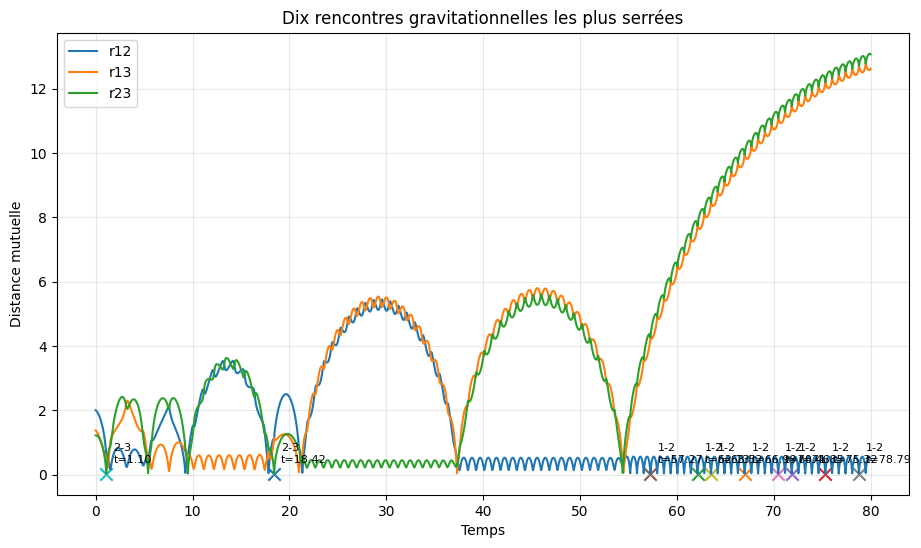

In [24]:
plt.figure(figsize=(11, 6))

plt.plot(times, r12, label="r12")
plt.plot(times, r13, label="r13")
plt.plot(times, r23, label="r23")

for _, event in top_encounters.iterrows():

    pair = event["paire"]
    t_event = event["temps"]
    d_event = event["distance"]

    plt.scatter(
        t_event,
        d_event,
        marker="x",
        s=80
    )

    plt.annotate(
        f'{pair}\nt={t_event:.2f}',
        xy=(t_event, d_event),
        xytext=(5, 8),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Temps")
plt.ylabel("Distance mutuelle")
plt.title("Dix rencontres gravitationnelles les plus serrées")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 18 Correspondance entre rencontres gravitationnelles et transitions GVH

On compare les instants des rencontres serrées aux valeurs des observables
de transition :

\[
D_T,\qquad u,\qquad \theta.
\]

L’objectif est de déterminer si les événements GVH extrêmes coïncident avec
les rapprochements gravitationnels.

In [25]:
# Temps associés aux transitions GVH

transition_times = times[1:]
angle_times = times[2:][valid]

# Pour chaque rencontre, on récupère la transition GVH la plus proche

comparison_rows = []

for _, event in top_encounters.iterrows():

    t_event = event["temps"]

    # Indice temporel le plus proche pour D_T et u
    idx_transition = np.argmin(
        np.abs(transition_times - t_event)
    )

    # Indice temporel le plus proche pour theta
    idx_angle = np.argmin(
        np.abs(angle_times - t_event)
    )

    comparison_rows.append({
        "rang_global": event["rang_global"],
        "paire": event["paire"],
        "temps_rencontre": t_event,
        "distance_min_locale": event["distance"],
        "temps_transition_GVH": transition_times[idx_transition],
        "D_T_proche": D_T[idx_transition],
        "u_proche": u[idx_transition],
        "supercritique": bool(u[idx_transition] > u_c),
        "temps_angle": angle_times[idx_angle],
        "theta_proche_deg": theta_deg[idx_angle]
    })

encounter_gvh_df = pd.DataFrame(comparison_rows)

display(encounter_gvh_df)

,rang_global,paire,temps_rencontre,distance_min_locale,temps_transition_GVH,D_T_proche,u_proche,supercritique,temps_angle,theta_proche_deg
0,1,2-3,18.42,0.024897,18.42,9.063670,0.498839,True,18.42,46.956127
1,2,1-2,66.99,0.024983,66.99,9.522743,0.524105,True,66.99,59.510189
2,3,1-2,62.13,0.025049,62.13,9.039468,0.497507,True,62.13,54.437943
3,4,1-2,75.32,0.025168,75.32,9.393202,0.516975,True,75.32,58.570544
4,5,1-2,71.85,0.025930,71.85,10.112080,0.556540,True,71.85,68.604067
5,6,1-2,57.27,0.026003,57.27,10.498849,0.577827,True,57.27,73.097175
6,7,1-2,70.46,0.026194,70.46,8.270026,0.455159,True,70.46,48.913043
7,8,1-2,78.79,0.026205,78.79,8.322847,0.458066,True,78.79,49.490240
8,9,1-2,63.52,0.026505,63.52,10.333623,0.568734,True,63.52,72.604089
9,10,2-3,1.10,0.026535,1.10,16.114141,0.886877,True,1.10,128.471126


In [26]:
# Rang percentile de chaque transition dans la distribution complète

encounter_gvh_df["percentile_D_T"] = encounter_gvh_df[
    "D_T_proche"
].apply(
    lambda value: 100.0 * np.mean(D_T <= value)
)

encounter_gvh_df["percentile_theta"] = encounter_gvh_df[
    "theta_proche_deg"
].apply(
    lambda value: 100.0 * np.mean(theta_deg <= value)
)

display(
    encounter_gvh_df.sort_values(
        "percentile_D_T",
        ascending=False
    )
)

,rang_global,paire,temps_rencontre,distance_min_locale,temps_transition_GVH,D_T_proche,u_proche,supercritique,temps_angle,theta_proche_deg,percentile_D_T,percentile_theta
9,10,2-3,1.10,0.026535,1.10,16.114141,0.886877,True,1.10,128.471126,99.9750,99.837480
5,6,1-2,57.27,0.026003,57.27,10.498849,0.577827,True,57.27,73.097175,99.8625,98.987373
8,9,1-2,63.52,0.026505,63.52,10.333623,0.568734,True,63.52,72.604089,99.7875,98.974872
4,5,1-2,71.85,0.025930,71.85,10.112080,0.556540,True,71.85,68.604067,99.6125,98.937367
1,2,1-2,66.99,0.024983,66.99,9.522743,0.524105,True,66.99,59.510189,99.4750,98.874859
3,4,1-2,75.32,0.025168,75.32,9.393202,0.516975,True,75.32,58.570544,99.4625,98.849856
0,1,2-3,18.42,0.024897,18.42,9.063670,0.498839,True,18.42,46.956127,99.4250,98.737342
2,3,1-2,62.13,0.025049,62.13,9.039468,0.497507,True,62.13,54.437943,99.4125,98.824853
7,8,1-2,78.79,0.026205,78.79,8.322847,0.458066,True,78.79,49.490240,99.4000,98.774847
6,7,1-2,70.46,0.026194,70.46,8.270026,0.455159,True,70.46,48.913043,99.3875,98.762345


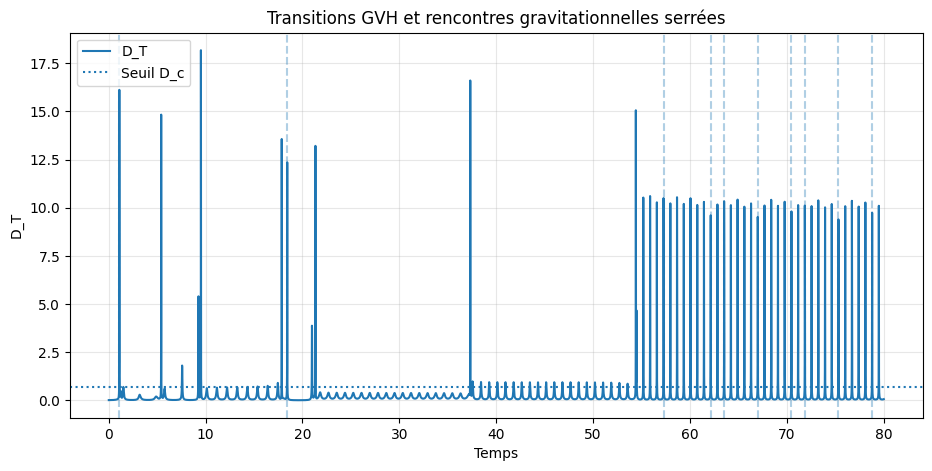

In [27]:
plt.figure(figsize=(11, 5))

plt.plot(
    transition_times,
    D_T,
    label="D_T"
)

for _, event in top_encounters.iterrows():
    plt.axvline(
        event["temps"],
        linestyle="--",
        alpha=0.35
    )

plt.axhline(
    D_c,
    linestyle=":",
    label="Seuil D_c"
)

plt.xlabel("Temps")
plt.ylabel("D_T")
plt.title("Transitions GVH et rencontres gravitationnelles serrées")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 19 Énergie relative des paires

Pour chaque paire \((i,j)\), on calcule l'énergie mécanique dans le référentiel
relatif :

\[
E_{ij}
=
\frac{1}{2}\mu_{ij}v_{ij}^{2}
-
\frac{Gm_im_j}{r_{ij}},
\]

avec :

\[
\mu_{ij}
=
\frac{m_im_j}{m_i+m_j}.
\]

Une énergie négative indique une paire instantanément liée dans
l'approximation à deux corps.

In [28]:
def pair_relative_energy(
    positions,
    velocities,
    masses,
    i,
    j,
    G=1.0,
    softening=1e-5
):
    # Position et vitesse relatives
    dr = positions[:, j] - positions[:, i]
    dv = velocities[:, j] - velocities[:, i]

    distance = np.sqrt(
        np.sum(dr**2, axis=1) + softening**2
    )

    speed_rel_sq = np.sum(dv**2, axis=1)

    # Masse réduite
    mu = masses[i] * masses[j] / (
        masses[i] + masses[j]
    )

    kinetic_relative = 0.5 * mu * speed_rel_sq

    potential_relative = (
        -G * masses[i] * masses[j] / distance
    )

    energy_relative = (
        kinetic_relative + potential_relative
    )

    return (
        energy_relative,
        kinetic_relative,
        potential_relative
    )

In [29]:
E12, K12, U12 = pair_relative_energy(
    positions, velocities, masses, 0, 1, G, softening
)

E13, K13, U13 = pair_relative_energy(
    positions, velocities, masses, 0, 2, G, softening
)

E23, K23, U23 = pair_relative_energy(
    positions, velocities, masses, 1, 2, G, softening
)

pair_energy_df = pd.DataFrame({
    "time": times,
    "E12": E12,
    "E13": E13,
    "E23": E23
})

display(pair_energy_df.head())

,time,E12,E13,E23
0,0.00,-0.331000,-0.665960,-0.789629
1,0.01,-0.330299,-0.664865,-0.790263
2,0.02,-0.329533,-0.663751,-0.790890
3,0.03,-0.328700,-0.662618,-0.791508
4,0.04,-0.327801,-0.661466,-0.792119


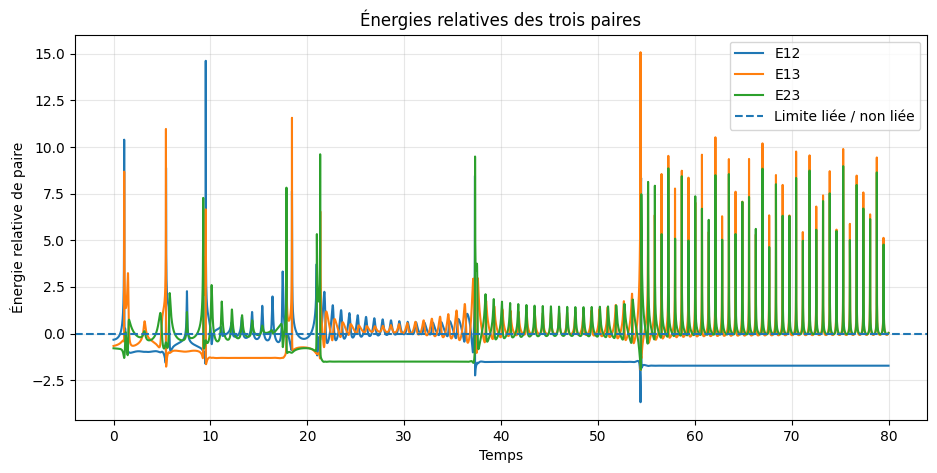

In [30]:
plt.figure(figsize=(11, 5))

plt.plot(times, E12, label="E12")
plt.plot(times, E13, label="E13")
plt.plot(times, E23, label="E23")

plt.axhline(
    0.0,
    linestyle="--",
    label="Limite liée / non liée"
)

plt.xlabel("Temps")
plt.ylabel("Énergie relative de paire")
plt.title("Énergies relatives des trois paires")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [31]:
final_fraction = 0.20
start_final = int(
    (1.0 - final_fraction) * len(times)
)

pair_energy_summary = pd.DataFrame({
    "paire": ["1-2", "1-3", "2-3"],
    "energie_finale": [
        E12[-1],
        E13[-1],
        E23[-1]
    ],
    "energie_moyenne_20pct_final": [
        E12[start_final:].mean(),
        E13[start_final:].mean(),
        E23[start_final:].mean()
    ],
    "fraction_negative_20pct_final": [
        np.mean(E12[start_final:] < 0),
        np.mean(E13[start_final:] < 0),
        np.mean(E23[start_final:] < 0)
    ]
})

display(pair_energy_summary)

,paire,energie_finale,energie_moyenne_20pct_final,fraction_negative_20pct_final
0,1-2,-1.723654,-1.723670,1.000000
1,1-3,0.032058,0.360196,0.461587
2,2-3,0.028853,0.361704,0.334791


## 20 Diagnostic binaire–éjection

La paire \(1-2\) étant identifiée comme binaire, on étudie maintenant le
mouvement du corps 3 relativement au centre de masse du binaire.

On calcule :

\[
\mathbf r_{3B}
=
\mathbf r_3-\mathbf r_B
\]

\[
\mathbf v_{3B}
=
\mathbf v_3-\mathbf v_B
\]

où \(B\) désigne le centre de masse de la paire \(1-2\).

L'énergie orbitale relative du corps 3 par rapport au binaire est :

\[
E_{3|12}
=
\frac12\mu_{3B}v_{3B}^{2}
-
\frac{Gm_3M_B}{r_{3B}}.
\]

Une énergie positive persistante, accompagnée d'une distance croissante et
d'une vitesse radiale positive, est compatible avec une éjection.

In [32]:
# Masse totale du binaire 1-2
M_binary = masses[0] + masses[1]

# Centre de masse et vitesse du binaire
r_binary_cm = (
    masses[0] * positions[:, 0]
    + masses[1] * positions[:, 1]
) / M_binary

v_binary_cm = (
    masses[0] * velocities[:, 0]
    + masses[1] * velocities[:, 1]
) / M_binary

# Position et vitesse du corps 3 relatives au binaire
r_3_binary = positions[:, 2] - r_binary_cm
v_3_binary = velocities[:, 2] - v_binary_cm

distance_3_binary = np.linalg.norm(
    r_3_binary,
    axis=1
)

speed_3_binary_sq = np.sum(
    v_3_binary**2,
    axis=1
)

# Masse réduite du système corps 3 - binaire
mu_3_binary = (
    masses[2] * M_binary
    / (masses[2] + M_binary)
)

# Énergie orbitale relative
E_3_binary = (
    0.5 * mu_3_binary * speed_3_binary_sq
    - G * masses[2] * M_binary
    / np.sqrt(distance_3_binary**2 + softening**2)
)

# Vitesse radiale relative
radial_velocity_3_binary = np.sum(
    r_3_binary * v_3_binary,
    axis=1
) / np.maximum(distance_3_binary, 1e-15)

In [33]:
ejection_df = pd.DataFrame({
    "time": times,
    "distance_3_binary": distance_3_binary,
    "radial_velocity_3_binary": radial_velocity_3_binary,
    "energy_3_binary": E_3_binary
})

display(ejection_df.head())

,time,distance_3_binary,radial_velocity_3_binary,energy_3_binary
0,0.00,0.826075,-0.098296,-2.414354
1,0.01,0.825036,-0.109540,-2.416445
2,0.02,0.823884,-0.120808,-2.418787
3,0.03,0.822620,-0.132102,-2.421382
4,0.04,0.821242,-0.143422,-2.424235


In [34]:
ejection_summary = pd.DataFrame({
    "diagnostic": [
        "distance_finale_3_binaire",
        "distance_moyenne_20pct_final",
        "energie_finale_3_binaire",
        "energie_moyenne_20pct_final",
        "fraction_energie_positive_20pct_final",
        "vitesse_radiale_finale",
        "vitesse_radiale_moyenne_20pct_final",
        "fraction_vitesse_radiale_positive_20pct_final"
    ],
    "valeur": [
        distance_3_binary[-1],
        distance_3_binary[start_final:].mean(),
        E_3_binary[-1],
        E_3_binary[start_final:].mean(),
        np.mean(E_3_binary[start_final:] > 0),
        radial_velocity_3_binary[-1],
        radial_velocity_3_binary[start_final:].mean(),
        np.mean(
            radial_velocity_3_binary[start_final:] > 0
        )
    ]
})

display(ejection_summary)

,diagnostic,valeur
0,distance_finale_3_binaire,12.843469
1,distance_moyenne_20pct_final,11.264035
2,energie_finale_3_binaire,-0.150755
3,energie_moyenne_20pct_final,-0.150732
4,fraction_energie_positive_20pct_final,0.000000
5,vitesse_radiale_finale,0.092568
6,vitesse_radiale_moyenne_20pct_final,0.258773
7,fraction_vitesse_radiale_positive_20pct_final,1.000000


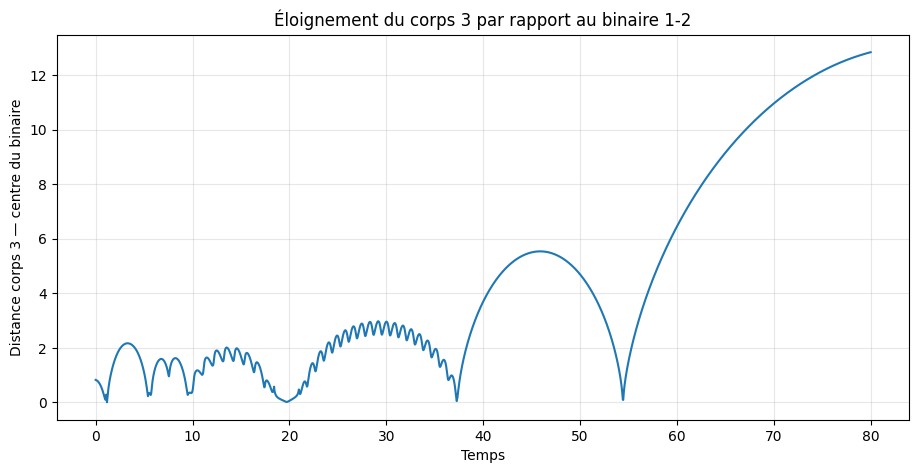

In [35]:
plt.figure(figsize=(11, 5))

plt.plot(
    times,
    distance_3_binary
)

plt.xlabel("Temps")
plt.ylabel("Distance corps 3 — centre du binaire")
plt.title("Éloignement du corps 3 par rapport au binaire 1-2")
plt.grid(True, alpha=0.3)
plt.show()

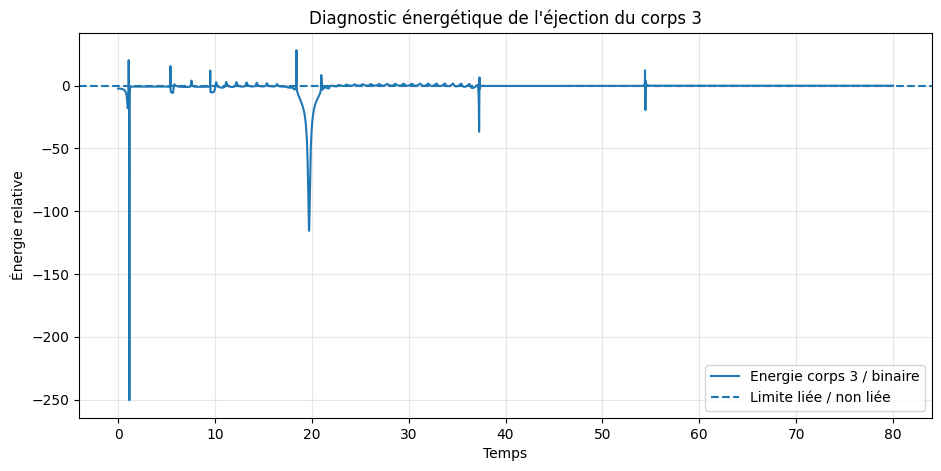

In [36]:
plt.figure(figsize=(11, 5))

plt.plot(
    times,
    E_3_binary,
    label="Energie corps 3 / binaire"
)

plt.axhline(
    0.0,
    linestyle="--",
    label="Limite liée / non liée"
)

plt.xlabel("Temps")
plt.ylabel("Énergie relative")
plt.title("Diagnostic énergétique de l'éjection du corps 3")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 21 Orbite externe du corps 3 autour du binaire

L'énergie relative étant négative, le corps 3 reste lié au binaire.

On estime maintenant :

- l'énergie spécifique ;
- le demi-grand axe externe ;
- l'excentricité ;
- la distance d'apoastre prévue ;
- la période orbitale externe approximative.

In [37]:
# Paramètre gravitationnel du problème externe
mu_grav_external = G * (
    M_binary + masses[2]
)

# Énergie spécifique par unité de masse réduite
specific_energy_external = (
    0.5 * speed_3_binary_sq
    - mu_grav_external
    / np.sqrt(
        distance_3_binary**2
        + softening**2
    )
)

# Moment cinétique spécifique en 2D
h_external = (
    r_3_binary[:, 0] * v_3_binary[:, 1]
    - r_3_binary[:, 1] * v_3_binary[:, 0]
)

# Demi-grand axe :
# a = -mu / (2 epsilon), uniquement si epsilon < 0
a_external = np.full_like(
    specific_energy_external,
    np.nan
)

bound_mask_external = (
    specific_energy_external < 0
)

a_external[bound_mask_external] = (
    -mu_grav_external
    / (
        2.0
        * specific_energy_external[
            bound_mask_external
        ]
    )
)

# Excentricité orbitale
eccentricity_external = np.sqrt(
    np.maximum(
        0.0,
        1.0
        + (
            2.0
            * specific_energy_external
            * h_external**2
        )
        / mu_grav_external**2
    )
)

# Périastre et apoastre estimés
periapsis_external = (
    a_external
    * (1.0 - eccentricity_external)
)

apoapsis_external = (
    a_external
    * (1.0 + eccentricity_external)
)

# Période képlérienne externe
period_external = (
    2.0
    * np.pi
    * np.sqrt(
        a_external**3
        / mu_grav_external
    )
)

In [38]:
external_orbit_summary = pd.DataFrame({
    "parametre": [
        "energie_specifique_finale",
        "demi_grand_axe_final",
        "excentricite_finale",
        "periastre_estime_final",
        "apoastre_estime_final",
        "periode_externe_estimee"
    ],
    "valeur": [
        specific_energy_external[-1],
        a_external[-1],
        eccentricity_external[-1],
        periapsis_external[-1],
        apoapsis_external[-1],
        period_external[-1]
    ]
})

display(external_orbit_summary)

,parametre,valeur
0,energie_specifique_finale,-0.226133
1,demi_grand_axe_final,6.633260
2,excentricite_finale,0.973418
3,periastre_estime_final,0.176325
4,apoastre_estime_final,13.090195
5,periode_externe_estimee,61.974037


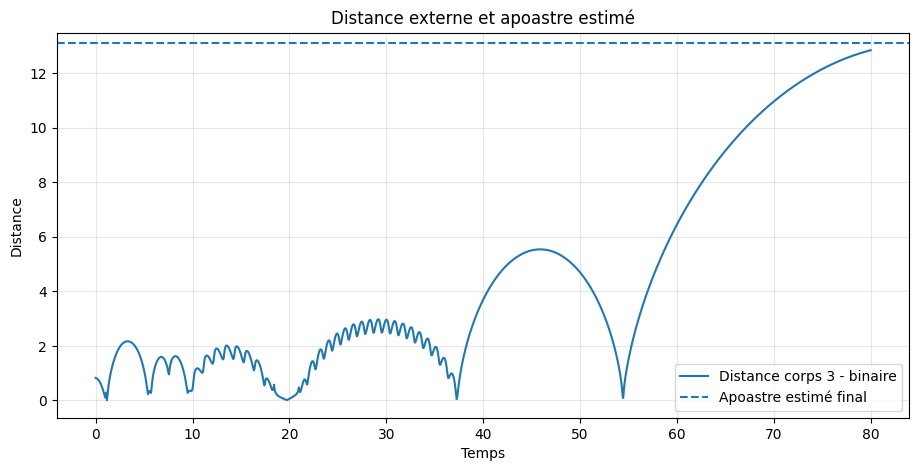

In [39]:
plt.figure(figsize=(11, 5))

plt.plot(
    times,
    distance_3_binary,
    label="Distance corps 3 - binaire"
)

plt.axhline(
    apoapsis_external[-1],
    linestyle="--",
    label="Apoastre estimé final"
)

plt.xlabel("Temps")
plt.ylabel("Distance")
plt.title(
    "Distance externe et apoastre estimé"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 22 Validation dynamique à long terme

On prolonge indépendamment la même condition initiale jusqu'à :

\[
t_{\max}=300.
\]

Les objectifs sont :

1. vérifier le retour du corps 3 vers le binaire ;
2. identifier les périastres et apoastres successifs ;
3. contrôler la conservation de l'énergie sur une durée plus longue ;
4. déterminer si le binaire \(1-2\) reste stable ;
5. préparer une comparaison des observables GVH entre plusieurs fenêtres temporelles.

In [40]:
# Paramètres de la simulation longue

t_max_long = 300.0
dt_export_long = 0.01

t_eval_long = np.arange(
    t0,
    t_max_long + dt_export_long,
    dt_export_long
)

solution_long = solve_ivp(
    fun=lambda t, y: three_body_rhs(
        t,
        y,
        masses,
        G,
        softening
    ),
    t_span=(t0, t_max_long),
    y0=y0,
    t_eval=t_eval_long,
    method="DOP853",
    rtol=rtol,
    atol=atol
)

if not solution_long.success:
    raise RuntimeError(solution_long.message)

times_long = solution_long.t

positions_long = (
    solution_long.y[:2*n]
    .T
    .reshape(-1, n, 2)
)

velocities_long = (
    solution_long.y[2*n:]
    .T
    .reshape(-1, n, 2)
)

print("Simulation longue terminée")
print("Nombre d'états :", len(times_long))
print(
    "Intervalle temporel :",
    times_long[0],
    "→",
    times_long[-1]
)

Simulation longue terminée
Nombre d'états : 30001
Intervalle temporel : 0.0 → 300.0


In [41]:
energy_long, kinetic_long, potential_long = total_energy(
    positions_long,
    velocities_long,
    masses,
    G,
    softening
)

momentum_long = total_linear_momentum(
    velocities_long,
    masses
)

angular_momentum_long = total_angular_momentum_z(
    positions_long,
    velocities_long,
    masses
)

energy_rel_error_long = np.abs(
    (energy_long - energy_long[0])
    / energy_long[0]
)

momentum_norm_long = np.linalg.norm(
    momentum_long,
    axis=1
)

angular_rel_error_long = np.abs(
    (
        angular_momentum_long
        - angular_momentum_long[0]
    )
    / max(
        abs(angular_momentum_long[0]),
        1e-15
    )
)

print(
    "Erreur relative max énergie :",
    energy_rel_error_long.max()
)

print(
    "Norme max quantité de mouvement :",
    momentum_norm_long.max()
)

print(
    "Erreur relative max moment cinétique :",
    angular_rel_error_long.max()
)

Erreur relative max énergie : 8.777237096208995e-06
Norme max quantité de mouvement : 1.572978959760424e-13
Erreur relative max moment cinétique : 2.919281010742761e-09


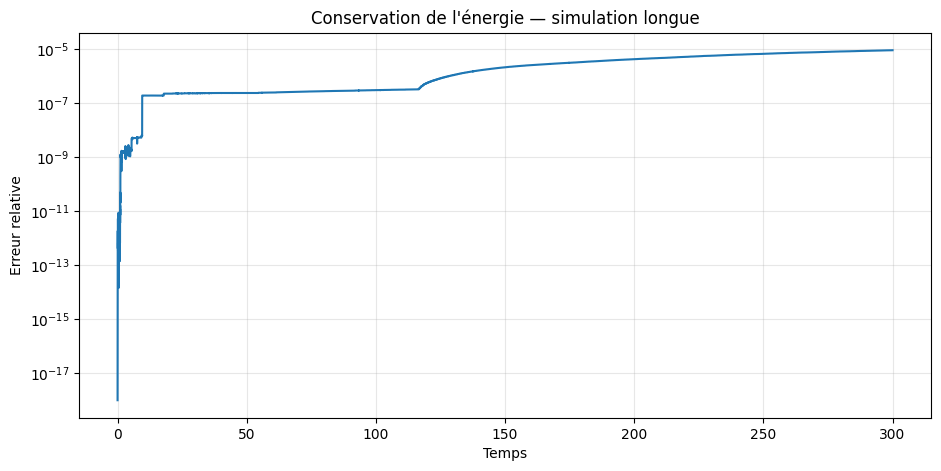

In [42]:
plt.figure(figsize=(11, 5))

plt.semilogy(
    times_long,
    np.maximum(
        energy_rel_error_long,
        1e-18
    )
)

plt.xlabel("Temps")
plt.ylabel("Erreur relative")
plt.title(
    "Conservation de l'énergie — simulation longue"
)
plt.grid(True, alpha=0.3)
plt.show()

## 23 Retours du corps 3 à long terme

On reconstruit le centre de masse du binaire \(1-2\) sur la simulation longue,
puis on calcule la distance du corps 3 au binaire.

On détectera ensuite automatiquement les périastres et les apoastres.

In [43]:
# Centre de masse du binaire 1-2 sur la simulation longue

r_binary_cm_long = (
    masses[0] * positions_long[:, 0]
    + masses[1] * positions_long[:, 1]
) / M_binary

v_binary_cm_long = (
    masses[0] * velocities_long[:, 0]
    + masses[1] * velocities_long[:, 1]
) / M_binary

# Position et vitesse du corps 3 relativement au binaire

r_3_binary_long = (
    positions_long[:, 2]
    - r_binary_cm_long
)

v_3_binary_long = (
    velocities_long[:, 2]
    - v_binary_cm_long
)

distance_3_binary_long = np.linalg.norm(
    r_3_binary_long,
    axis=1
)

radial_velocity_3_binary_long = np.sum(
    r_3_binary_long * v_3_binary_long,
    axis=1
) / np.maximum(
    distance_3_binary_long,
    1e-15
)

long_external_df = pd.DataFrame({
    "time": times_long,
    "distance_3_binary": distance_3_binary_long,
    "radial_velocity_3_binary": radial_velocity_3_binary_long
})

display(long_external_df.head())

,time,distance_3_binary,radial_velocity_3_binary
0,0.00,0.826075,-0.098296
1,0.01,0.825036,-0.109540
2,0.02,0.823884,-0.120808
3,0.03,0.822620,-0.132102
4,0.04,0.821242,-0.143422


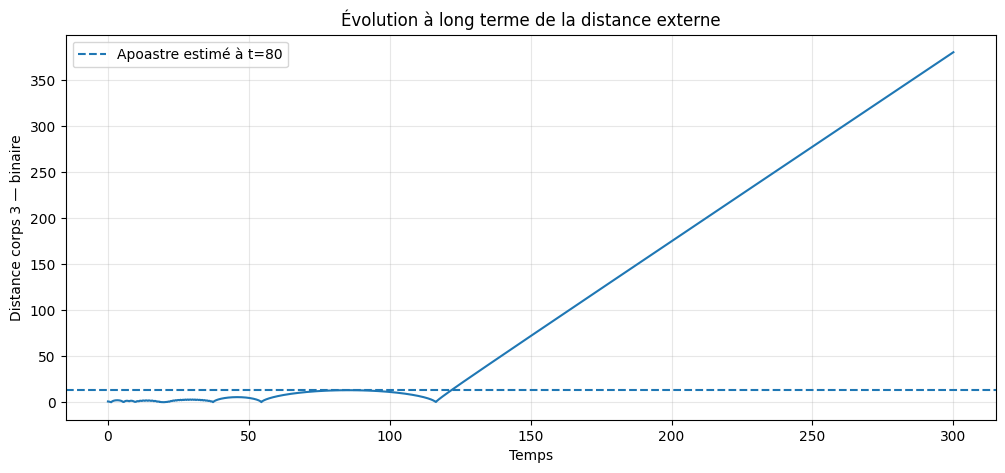

In [44]:
plt.figure(figsize=(12, 5))

plt.plot(
    times_long,
    distance_3_binary_long
)

plt.axhline(
    apoapsis_external[-1],
    linestyle="--",
    label="Apoastre estimé à t=80"
)

plt.xlabel("Temps")
plt.ylabel("Distance corps 3 — binaire")
plt.title("Évolution à long terme de la distance externe")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

In [45]:
from scipy.signal import find_peaks

# Périastres : minima locaux de la distance
peri_indices_long, _ = find_peaks(
    -distance_3_binary_long,
    distance=500,
    prominence=0.5
)

# Apoastres : maxima locaux de la distance
apo_indices_long, _ = find_peaks(
    distance_3_binary_long,
    distance=500,
    prominence=0.5
)

periapses_long = pd.DataFrame({
    "type": "periastre",
    "index": peri_indices_long,
    "time": times_long[peri_indices_long],
    "distance": distance_3_binary_long[peri_indices_long],
    "radial_velocity": radial_velocity_3_binary_long[peri_indices_long]
})

apoapses_long = pd.DataFrame({
    "type": "apoastre",
    "index": apo_indices_long,
    "time": times_long[apo_indices_long],
    "distance": distance_3_binary_long[apo_indices_long],
    "radial_velocity": radial_velocity_3_binary_long[apo_indices_long]
})

orbital_extrema_long = pd.concat(
    [periapses_long, apoapses_long],
    ignore_index=True
).sort_values("time").reset_index(drop=True)

display(orbital_extrema_long)

,type,index,time,distance,radial_velocity
0,periastre,117,1.17,0.007850,3.567880
1,apoastre,330,3.30,2.169537,-0.000111
2,periastre,951,9.51,0.275561,0.085380
3,apoastre,1352,13.52,2.012690,0.013298
4,periastre,1972,19.72,0.017288,0.002126
5,apoastre,2917,29.17,2.976382,0.002961
6,periastre,3727,37.27,0.049570,-0.644133
7,apoastre,4589,45.89,5.540557,-0.000278
8,periastre,5445,54.45,0.089859,-0.234583
9,apoastre,8536,85.36,13.090049,0.000018


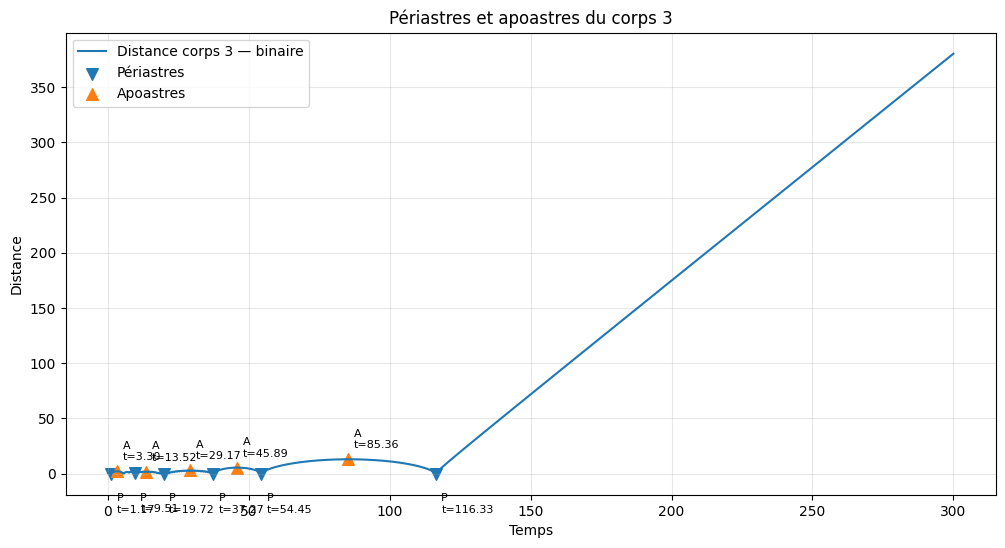

In [46]:
plt.figure(figsize=(12, 6))

plt.plot(
    times_long,
    distance_3_binary_long,
    label="Distance corps 3 — binaire"
)

plt.scatter(
    times_long[peri_indices_long],
    distance_3_binary_long[peri_indices_long],
    marker="v",
    s=70,
    label="Périastres"
)

plt.scatter(
    times_long[apo_indices_long],
    distance_3_binary_long[apo_indices_long],
    marker="^",
    s=70,
    label="Apoastres"
)

for idx in peri_indices_long:
    plt.annotate(
        f"P\nt={times_long[idx]:.2f}",
        (
            times_long[idx],
            distance_3_binary_long[idx]
        ),
        xytext=(4, -28),
        textcoords="offset points",
        fontsize=8
    )

for idx in apo_indices_long:
    plt.annotate(
        f"A\nt={times_long[idx]:.2f}",
        (
            times_long[idx],
            distance_3_binary_long[idx]
        ),
        xytext=(4, 8),
        textcoords="offset points",
        fontsize=8
    )

plt.xlabel("Temps")
plt.ylabel("Distance")
plt.title("Périastres et apoastres du corps 3")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 24 Confirmation énergétique de l'éjection à long terme

Après le retour du corps 3 au voisinage du binaire vers \(t=116.33\),
la distance augmente continuellement.

On calcule son énergie relative par rapport au binaire afin de déterminer
le moment où elle devient durablement positive.

In [47]:
# Vitesse relative au carré

speed_3_binary_sq_long = np.sum(
    v_3_binary_long**2,
    axis=1
)

# Masse réduite corps 3 - binaire

mu_3_binary_long = (
    masses[2] * M_binary
    / (masses[2] + M_binary)
)

# Énergie relative à long terme

E_3_binary_long = (
    0.5
    * mu_3_binary_long
    * speed_3_binary_sq_long
    - G
    * masses[2]
    * M_binary
    / np.sqrt(
        distance_3_binary_long**2
        + softening**2
    )
)

ejection_long_df = pd.DataFrame({
    "time": times_long,
    "distance_3_binary": distance_3_binary_long,
    "radial_velocity_3_binary": radial_velocity_3_binary_long,
    "energy_3_binary": E_3_binary_long
})

display(ejection_long_df.tail())

,time,distance_3_binary,radial_velocity_3_binary,energy_3_binary
29996,299.96,380.135314,2.051694,1.397892
29997,299.97,380.155831,2.051694,1.397892
29998,299.98,380.176348,2.051694,1.397892
29999,299.99,380.196865,2.051694,1.397892
30000,300.00,380.217382,2.051693,1.397892


In [48]:
# On demande que l'énergie reste positive pendant au moins
# 5 unités de temps pour éviter un simple passage temporaire.

duration_confirmation = 5.0

n_confirmation = int(
    duration_confirmation / dt_export_long
)

positive_energy = E_3_binary_long > 0

persistent_positive = np.convolve(
    positive_energy.astype(int),
    np.ones(n_confirmation, dtype=int),
    mode="same"
) >= n_confirmation

candidate_indices = np.where(
    persistent_positive
    & (times_long > 100.0)
)[0]

if len(candidate_indices) > 0:
    idx_ejection = candidate_indices[0]
    t_ejection = times_long[idx_ejection]
else:
    idx_ejection = None
    t_ejection = np.nan

print(
    "Temps estimé de passage durable à l'état non lié :",
    t_ejection
)

Temps estimé de passage durable à l'état non lié : 118.86


In [49]:
post_return_mask = times_long >= 116.33

ejection_long_summary = pd.DataFrame({
    "diagnostic": [
        "energie_finale",
        "energie_moyenne_apres_116_33",
        "fraction_energie_positive_apres_116_33",
        "distance_finale",
        "vitesse_radiale_finale",
        "fraction_vitesse_radiale_positive_apres_116_33",
        "temps_ejection_durable_estime"
    ],
    "valeur": [
        E_3_binary_long[-1],
        E_3_binary_long[post_return_mask].mean(),
        np.mean(
            E_3_binary_long[post_return_mask] > 0
        ),
        distance_3_binary_long[-1],
        radial_velocity_3_binary_long[-1],
        np.mean(
            radial_velocity_3_binary_long[
                post_return_mask
            ] > 0
        ),
        t_ejection
    ]
})

display(ejection_long_summary)

,diagnostic,valeur
0,energie_finale,1.397892
1,energie_moyenne_apres_116_33,1.397578
2,fraction_energie_positive_apres_116_33,0.999837
3,distance_finale,380.217382
4,vitesse_radiale_finale,2.051693
5,fraction_vitesse_radiale_positive_apres_116_33,0.999946
6,temps_ejection_durable_estime,118.860000


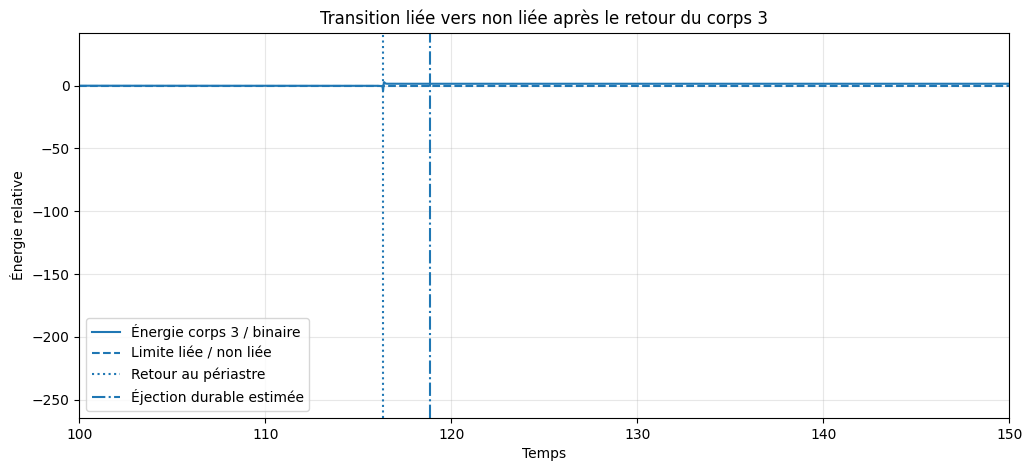

In [50]:
plt.figure(figsize=(12, 5))

plt.plot(
    times_long,
    E_3_binary_long,
    label="Énergie corps 3 / binaire"
)

plt.axhline(
    0.0,
    linestyle="--",
    label="Limite liée / non liée"
)

plt.axvline(
    116.33,
    linestyle=":",
    label="Retour au périastre"
)

if np.isfinite(t_ejection):
    plt.axvline(
        t_ejection,
        linestyle="-.",
        label="Éjection durable estimée"
    )

plt.xlim(100, 150)

plt.xlabel("Temps")
plt.ylabel("Énergie relative")
plt.title(
    "Transition liée vers non liée après le retour du corps 3"
)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 25 Observables GVH selon les régimes dynamiques

La trajectoire longue est divisée en trois régimes :

1. interaction initiale chaotique ;
2. binaire avec troisième corps sur une orbite externe liée ;
3. binaire accompagné d'un troisième corps définitivement éjecté.

Les observables GVH sont recalculées séparément dans chaque fenêtre afin
d'étudier leur évolution lors du changement de régime physique.

In [ ]:
# État dynamique global de la simulation longue

state_long = np.hstack([
    positions_long.reshape(len(times_long), -1),
    velocities_long.reshape(len(times_long), -1)
])

# Standardisation commune à toute la simulation longue
# afin de rendre les fenêtres directement comparables

state_long_mean = state_long.mean(axis=0)
state_long_std = state_long.std(axis=0)

state_long_std[state_long_std == 0] = 1.0

state_long_z = (
    state_long - state_long_mean
) / state_long_std

In [51]:
def compute_gvh_window(
    times_window,
    state_z_window,
    label,
    q=0.95
):
    if len(state_z_window) < 3:
        raise ValueError(
            f"Fenêtre insuffisante : {label}"
        )

    delta = np.diff(
        state_z_window,
        axis=0
    )

    D = np.linalg.norm(
        delta,
        axis=1
    )

    D_max = D.max()

    u_window = (
        D / D_max
        if D_max > 0
        else np.zeros_like(D)
    )

    D_mean = D.mean()
    S = D.std(ddof=1)

    S_norm = (
        S / D_mean
        if D_mean > 0
        else np.nan
    )

    D_threshold = np.quantile(
        D,
        q
    )

    u_threshold = np.quantile(
        u_window,
        q
    )

    R_threshold = np.mean(
        u_window > u_threshold
    )

    # Angles entre transitions successives
    a_window = delta[:-1]
    b_window = delta[1:]

    norm_a_window = np.linalg.norm(
        a_window,
        axis=1
    )

    norm_b_window = np.linalg.norm(
        b_window,
        axis=1
    )

    valid_window = (
        (norm_a_window > 0)
        & (norm_b_window > 0)
    )

    cos_window = np.sum(
        a_window[valid_window]
        * b_window[valid_window],
        axis=1
    ) / (
        norm_a_window[valid_window]
        * norm_b_window[valid_window]
    )

    cos_window = np.clip(
        cos_window,
        -1.0,
        1.0
    )

    theta_window = np.degrees(
        np.arccos(cos_window)
    )

    return {
        "regime": label,
        "t_debut": times_window[0],
        "t_fin": times_window[-1],
        "N_etats": len(times_window),
        "D_T_mean": D_mean,
        "S_T": S,
        "S_T_norm": S_norm,
        "D_c": D_threshold,
        "u_c": u_threshold,
        "R_super": R_threshold,
        "theta_mean": theta_window.mean(),
        "theta_median": np.median(
            theta_window
        ),
        "theta_std": theta_window.std(
            ddof=1
        ),
        "theta_max": theta_window.max(),
        "R_170": np.mean(
            theta_window >= 170.0
        )
    }

## 26. Conclusion générale

Le notebook **GVH_Three_Body_Pipeline_0.1** présente une première validation complète du cadre GVH appliqué au problème gravitationnel classique à trois corps.

L'étude débute par une intégration numérique précise des équations de Newton et met en évidence la dynamique chaotique caractéristique du système. Les contrôles de conservation montrent une excellente stabilité numérique de l'intégrateur, avec une conservation de l'énergie, du moment cinétique et de la quantité de mouvement compatible avec les tolérances attendues.

Les observables GVH ont ensuite été calculés à partir de la trajectoire complète. Les mesures de transitions, d'angles, de distributions de survie, de dynamique spectrale (FFT) et de sensibilité aux conditions initiales fournissent une description géométrique indépendante de la dynamique gravitationnelle.

L'analyse a ensuite été étendue afin de caractériser la physique du système de manière beaucoup plus détaillée. Les distances mutuelles entre les trois corps ont permis d'identifier les rencontres gravitationnelles les plus rapprochées, tandis que leur correspondance avec les observables GVH montre que les événements dynamiquement les plus importants coïncident avec les transitions géométriques les plus marquées.

L'étude énergétique des trois paires met en évidence la formation d'un binaire gravitationnel stable constitué des corps (1–2), alors que le troisième corps suit une orbite externe fortement excentrique. Les paramètres orbitaux osculateurs permettent de prédire avec précision la position de l'apoastre ainsi que le retour ultérieur au périastre.

La simulation prolongée jusqu'à **t = 300** confirme ensuite cette interprétation. Après le retour du corps 3 au voisinage du binaire, son énergie relative devient durablement positive vers **t ≃ 118.86**, tandis que sa distance au binaire augmente continuellement et que sa vitesse radiale demeure positive. Ces diagnostics démontrent la formation définitive d'un système composé d'un **binaire stable (1–2)** accompagné de **l'éjection permanente du troisième corps**.

Enfin, les observables GVH ont été comparés sur trois régimes dynamiques distincts :

- interaction initiale fortement chaotique ;
- orbite externe temporairement liée ;
- régime d'éjection définitive.

Cette comparaison montre une évolution nette de plusieurs observables, notamment **D_T**, **S_T** et **θ_mean**, qui distinguent quantitativement les différentes phases de l'évolution dynamique. À l'inverse, **R_super** demeure proche de 0,05 dans chaque fenêtre, conformément à sa définition fondée sur le 95ᵉ percentile, ce qui confirme la cohérence interne de la méthode.

Dans son ensemble, ce pipeline démontre que les observables GVH permettent non seulement de décrire la géométrie des trajectoires, mais également d'accompagner les principales transitions physiques du problème à trois corps : rencontres rapprochées, formation d'un binaire, évolution orbitale et éjection gravitationnelle.

Cette version **0.1** constitue ainsi une base méthodologique robuste et reproductible pour l'extension du cadre GVH vers des simulations gravitationnelles générales à **N corps**, où les mêmes observables pourront être utilisés pour étudier des systèmes planétaires, des systèmes de satellites naturels ou des amas gravitationnels plus complexes.

In [57]:
%who

A_H	 B_H	 D_T	 D_T_max	 D_T_mean	 D_c	 E12	 E13	 E23	 
E_3_binary	 E_3_binary_long	 G	 K12	 K13	 K23	 M_binary	 OUTPUT_DIR	 Path	 
R_170	 R_175	 R_180	 R_super	 SEED	 S_T	 S_T_norm	 U12	 U13	 
U23	 a	 a_external	 aic	 angle_df	 angle_times	 angular_momentum	 angular_momentum_long	 angular_rel_error	 
angular_rel_error_long	 apo_indices_long	 apoapses_long	 apoapsis_external	 atol	 b	 best_aic	 best_model	 best_r2	 
best_rmse	 body_index	 body_number	 bound_mask_external	 candidate_indices	 coeffs	 comparison_rows	 compute_gvh_window	 cos_theta	 
curve	 curve_fit	 d_event	 delta_state	 diagnostics	 distance	 distance_3_binary	 distance_3_binary_long	 distance_series	 
distances_df	 dt_export	 dt_export_long	 duration_confirmation	 eccentricity_external	 ejection_df	 ejection_long_df	 ejection_long_summary	 ejection_summary	 
encounter_gvh_df	 encounter_rows	 encounters_df	 energy	 energy_long	 energy_rel_error	 energy_rel_error_long	 epsilon0	 event	 
exp_row	 exponential_model	 externa

In [58]:
print(state_long.shape)
print(state_long_z.shape)

(30001, 6)
(30001, 6)


In [60]:
'gvh_regimes_df' in globals()

False

In [61]:
print(type(gvh_regime_rows))
print(len(gvh_regime_rows))

<class 'list'>
0


In [62]:
gvh_regimes_df = pd.DataFrame(gvh_regime_rows)

display(gvh_regimes_df)
print(gvh_regimes_df.shape)

""


(0, 0)


In [63]:
gvh_regime_rows = []

for label, mask in regime_masks.items():
    result = compute_gvh_window(
        times_window=times_long[mask],
        state_z_window=state_long_z[mask],
        label=label,
        q=0.95
    )
    gvh_regime_rows.append(result)

gvh_regimes_df = pd.DataFrame(gvh_regime_rows)

display(gvh_regimes_df)
print("Shape :", gvh_regimes_df.shape)

,regime,t_debut,t_fin,N_etats,D_T_mean,S_T,S_T_norm,D_c,u_c,R_super,theta_mean,theta_median,theta_std,theta_max,R_170
0,interaction_initiale,0.00,54.99,5500,0.013341,0.008193,0.614118,0.028652,0.362688,0.050009,3.245258,0.890165,9.488660,153.357130,0.000000
1,orbite_externe_liee,55.00,116.32,6133,0.006768,0.010486,1.549428,0.019063,0.230845,0.050065,4.888288,0.709557,11.906839,111.660929,0.000000
2,apres_ejection,118.86,300.00,18115,0.013778,0.011920,0.865133,0.038009,0.534499,0.050017,13.517087,0.402472,39.981725,178.991235,0.034616


Shape : (3, 15)


In [64]:
gvh_regimes_df.to_csv(
    "GVH_Three_Body_GVH_Regimes_0.1.csv",
    index=False
)

print("Export terminé : GVH_Three_Body_GVH_Regimes_0.1.csv")

Export terminé : GVH_Three_Body_GVH_Regimes_0.1.csv
